# Netflix User Behavior Analysis
**SkillInfyTech Data Science Internship — Project 3**

**Goal:** What can user data tell us about viewer preferences and trends on Netflix?

**Dataset:** Netflix Userbase Dataset (Kaggle) — subscription type, revenue, join/payment dates, country, device, plan duration.

**Pipeline:** Load → Clean → EDA → Pattern Detection → Correlation Analysis → Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('../data/Netflix_Userbase.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2500, 10)


,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   User ID            2500 non-null   int64
 1   Subscription Type  2500 non-null   str  
 2   Monthly Revenue    2500 non-null   int64
 3   Join Date          2500 non-null   str  
 4   Last Payment Date  2500 non-null   str  
 5   Country            2500 non-null   str  
 6   Age                2500 non-null   int64
 7   Gender             2500 non-null   str  
 8   Device             2500 non-null   str  
 9   Plan Duration      2500 non-null   str  
dtypes: int64(3), str(7)
memory usage: 195.4 KB


In [4]:
print('Missing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values:
User ID              0
Subscription Type    0
Monthly Revenue      0
Join Date            0
Last Payment Date    0
Country              0
Age                  0
Gender               0
Device               0
Plan Duration        0
dtype: int64

Duplicate rows: 0


## 2. Data Cleaning

In [5]:
# Standardise column names (snake_case, no spaces)
df.columns = [c.strip().replace(' ', '_') for c in df.columns]
print(df.columns.tolist())

['User_ID', 'Subscription_Type', 'Monthly_Revenue', 'Join_Date', 'Last_Payment_Date', 'Country', 'Age', 'Gender', 'Device', 'Plan_Duration']


In [6]:
# Convert date columns to datetime (adjust column names if they differ after inspecting above)
date_cols = [c for c in df.columns if 'Date' in c]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

print('Date columns converted:', date_cols)
df[date_cols].head()

Date columns converted: ['Join_Date', 'Last_Payment_Date']


,Join_Date,Last_Payment_Date
0,2022-01-15,2023-06-10
1,2021-09-05,2023-06-22
2,2023-02-28,2023-06-27
3,2022-07-10,2023-06-26
4,2023-05-01,2023-06-28


## 3. Exploratory Data Analysis

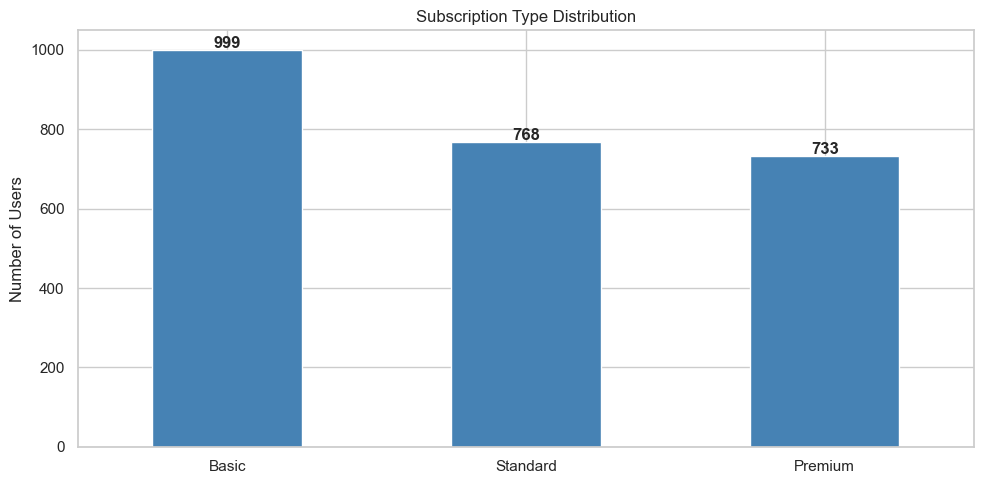

In [7]:
# --- 3.1 Subscription Type Distribution ---
fig, ax = plt.subplots()
sub_counts = df['Subscription_Type'].value_counts()
sub_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Subscription Type Distribution')
ax.set_ylabel('Number of Users')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(sub_counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

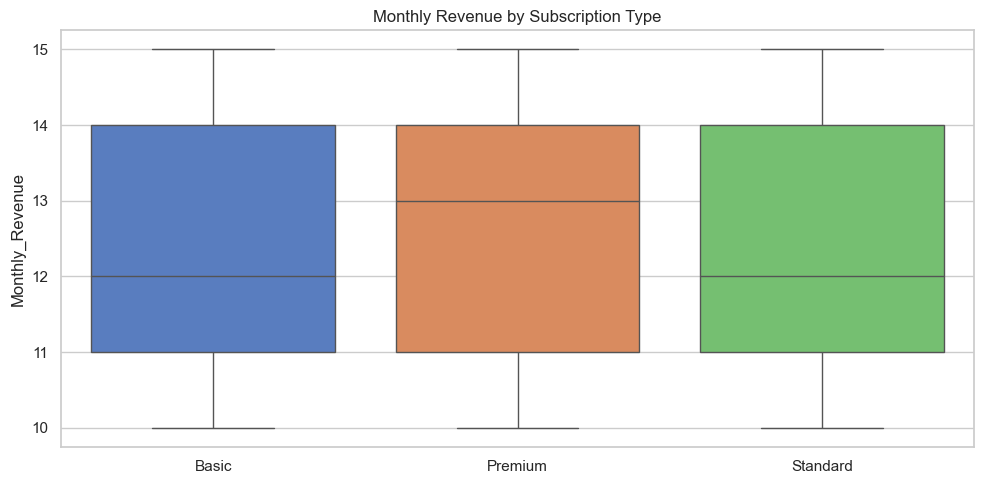

In [8]:
# --- 3.2 Monthly Revenue by Subscription Type ---
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Subscription_Type', y='Monthly_Revenue', ax=ax, palette='muted')
ax.set_title('Monthly Revenue by Subscription Type')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

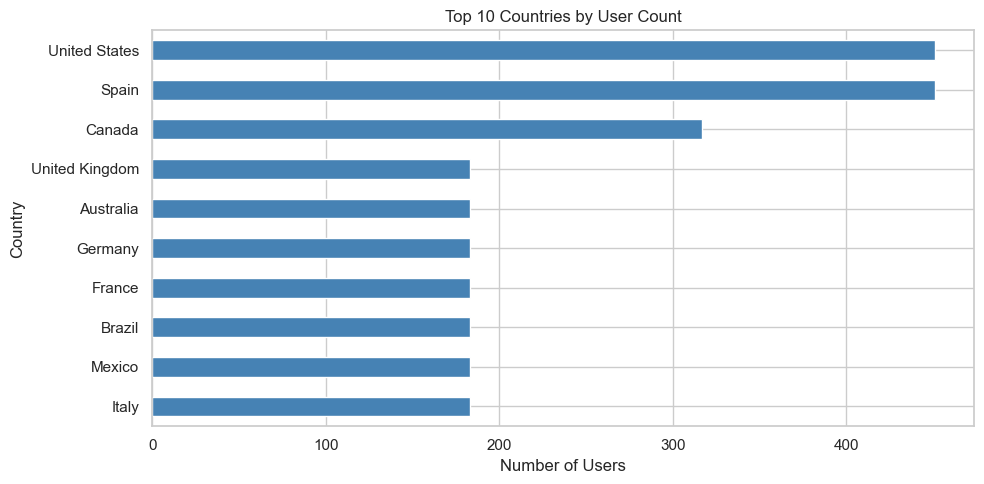

In [9]:
# --- 3.3 Users by Country (Top 10) ---
fig, ax = plt.subplots()
top_countries = df['Country'].value_counts().head(10)
top_countries.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 Countries by User Count')
ax.set_xlabel('Number of Users')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

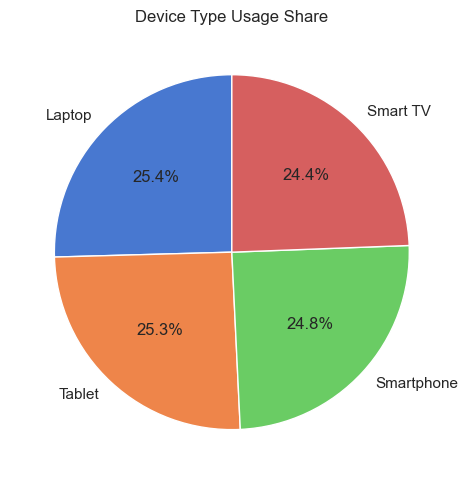

In [10]:
# --- 3.4 Device Type Preferences ---
fig, ax = plt.subplots()
device_counts = df['Device'].value_counts()
colors = sns.color_palette('muted', len(device_counts))
ax.pie(device_counts, labels=device_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Device Type Usage Share')
plt.tight_layout()
plt.show()

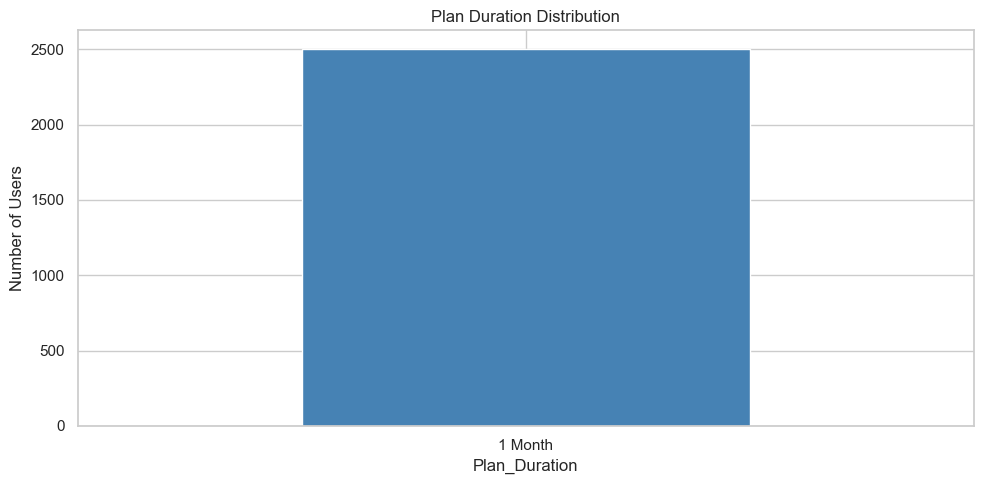

Plan_Duration
1 Month    100.0
Name: count, dtype: float64


In [11]:
# --- 3.5 Plan Duration Breakdown ---
fig, ax = plt.subplots()
duration_counts = df['Plan_Duration'].value_counts()
duration_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Plan Duration Distribution')
ax.set_ylabel('Number of Users')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print((duration_counts / duration_counts.sum() * 100).round(1))

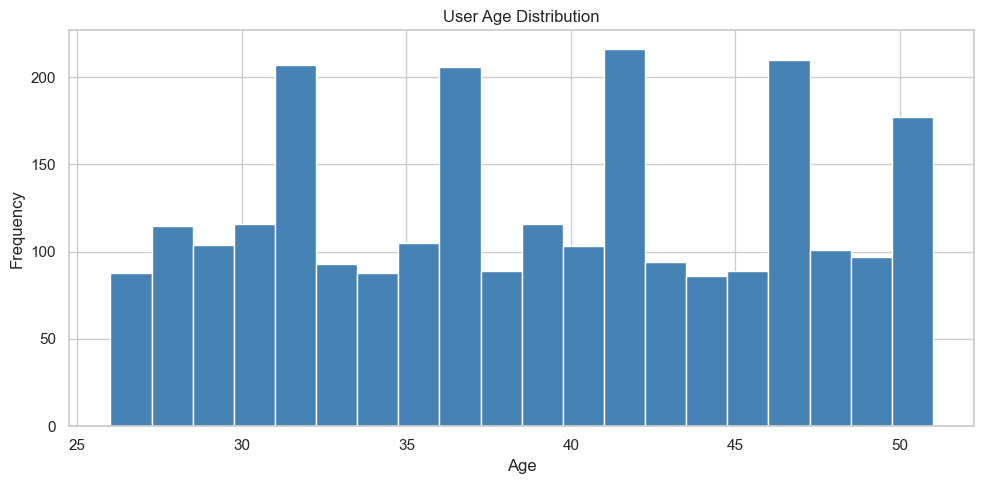

In [12]:
# --- 3.6 Age Distribution ---
fig, ax = plt.subplots()
df['Age'].plot(kind='hist', bins=20, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('User Age Distribution')
ax.set_xlabel('Age')
plt.tight_layout()
plt.show()

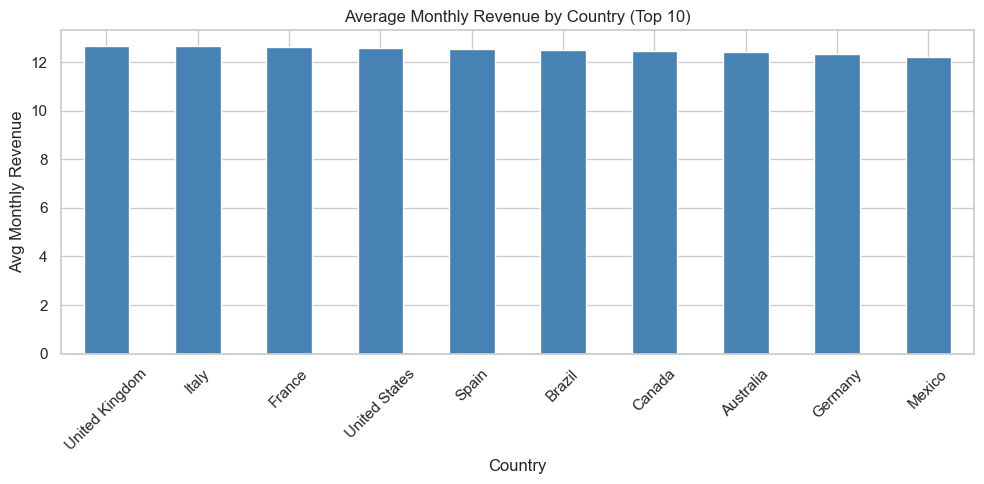

In [13]:
# --- 3.7 Revenue by Country (Top 10) ---
fig, ax = plt.subplots()
revenue_by_country = df.groupby('Country')['Monthly_Revenue'].mean().sort_values(ascending=False).head(10)
revenue_by_country.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Average Monthly Revenue by Country (Top 10)')
ax.set_ylabel('Avg Monthly Revenue')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

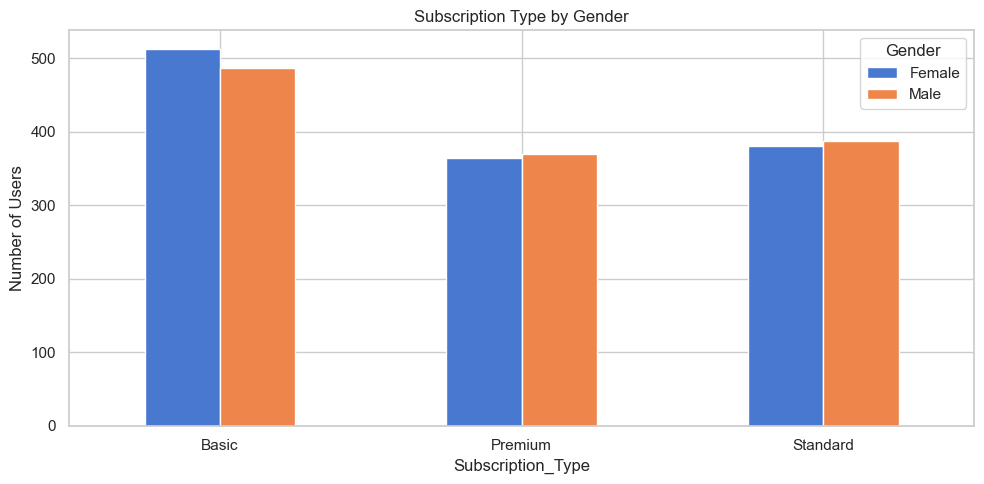

In [14]:
# --- 3.8 Gender vs Subscription Type ---
fig, ax = plt.subplots()
cross = pd.crosstab(df['Subscription_Type'], df['Gender'])
cross.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Subscription Type by Gender')
ax.set_ylabel('Number of Users')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 4. Pattern Detection & Correlation Analysis

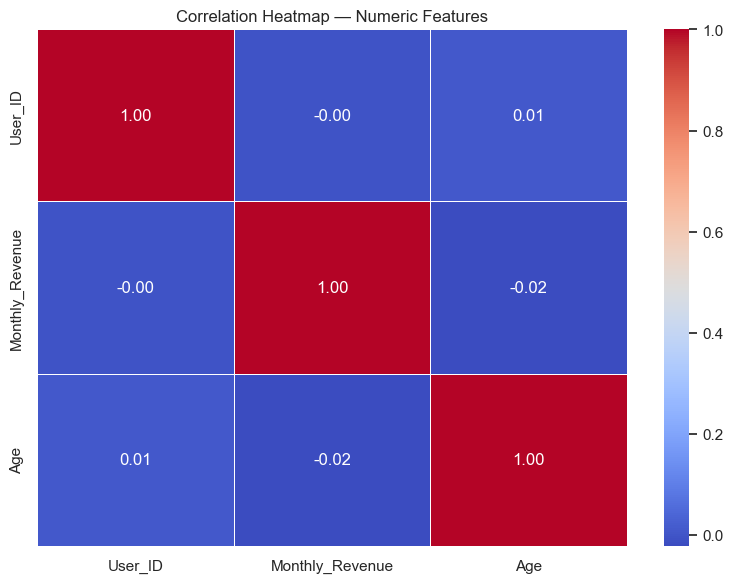

In [15]:
# --- 4.1 Correlation Heatmap (numeric features) ---
fig, ax = plt.subplots(figsize=(8, 6))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

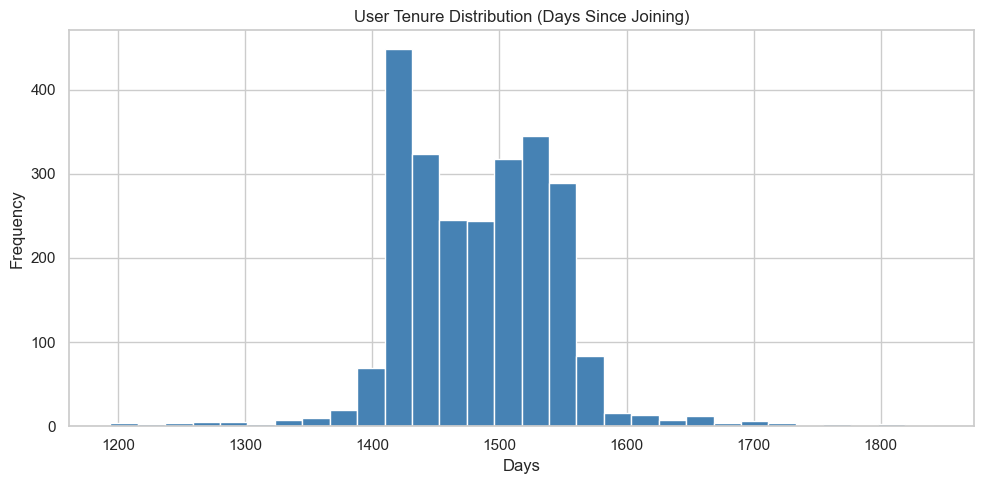

In [16]:
# --- 4.2 Tenure: Days since joining ---
join_col = [c for c in df.columns if 'Join' in c]
if join_col:
    join_col = join_col[0]
    df['Tenure_Days'] = (pd.Timestamp.today() - df[join_col]).dt.days
    fig, ax = plt.subplots()
    df['Tenure_Days'].plot(kind='hist', bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('User Tenure Distribution (Days Since Joining)')
    ax.set_xlabel('Days')
    plt.tight_layout()
    plt.show()

## 5. Key Insights Summary

- **Most popular subscription plan:** Basic (999 users, ~40%), followed by Standard (768) and Premium (733)
- **Highest-revenue country:** UK, Italy, and France lead (~$12.6/month avg), though revenue is fairly uniform across all 10 countries
- **Dominant device type:** No single dominant device — usage is nearly evenly split across Laptop, Tablet, Smartphone, and Smart TV (~24-25% each)
- **Plan duration:** All users are on 1-month plans — the dataset doesn't capture longer commitment tiers, limiting churn/loyalty analysis
- **Age group most represented:** Users span 26-51 fairly evenly, with slight peaks around 31, 36, 41, and 46
- **Notable correlation:** No meaningful correlation between Age, Monthly Revenue, or User ID — revenue is driven by plan tier, not demographics

**Business takeaway:** Since device usage and revenue are nearly uniform across segments, there's no single "high-value" user profile in this data — retention and upsell strategies would need to focus on the subscription tier itself (e.g., converting Basic users to Standard/Premium) rather than targeting by device or country.